# Stochastic Optimization

## Exercise on Control

<a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" align="left" src="https://i.creativecommons.org/l/by-sa/4.0/80x15.png" /></a>&nbsp;| Dennis G. Wilson | <a href="https://supaerodatascience.github.io/stochastic/">https://supaerodatascience.github.io/stochastic/</a>

Today you'll explore advanced SGD methods (momentum, Adam) and compare them with gradient-free approaches on a robotic arm control problem. You'll also learn automatic differentiation with JAX.

In [201]:
# Setup and Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import jax
import jax.numpy as jnp
from jax import grad, jit
from typing import Tuple, List, Callable
import time

# Set random seeds for reproducibility
np.random.seed(42)

# Enable JAX to run on CPU (for consistent behavior across platforms)
jax.config.update('jax_platform_name', 'cpu')

print("Setup complete! JAX version:", jax.__version__)
print("NumPy version:", np.__version__)

Setup complete! JAX version: 0.7.2
NumPy version: 2.0.2


# Exploring the Robot Arm
Run the provided visualization to understand the 2-joint planar arm. Experiment with different joint angles. We will experiment with two different libraries for this robot arm: numpy and [jax](docs.jax.dev/en/latest/index.html). Jax will enable easier gradient calculations through [automatic differentiation](https://huggingface.co/blog/andmholm/what-is-automatic-differentiation). For now, understand and explore this 2-joint robot arm which uses two angles to calculate the end position of the arm.

In [202]:
def forward_kinematics_numpy(theta: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    """
    Compute end-effector position for a 2-joint planar arm.

    Parameters:
    -----------
    theta : np.ndarray, shape (2,)
        Joint angles [theta1, theta2] in radians
    lengths : np.ndarray, shape (2,)
        Link lengths [L1, L2]

    Returns:
    --------
    position : np.ndarray, shape (2,)
        End-effector position [x, y]
    """
    theta1, theta2 = theta
    L1, L2 = lengths

    # First joint position
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)

    # End-effector position
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)

    return np.array([x2, y2])

In [203]:
# JAX version (for automatic differentiation)
def forward_kinematics_jax(theta: jnp.ndarray, lengths: jnp.ndarray) -> jnp.ndarray:
    """
    Compute end-effector position for a 2-joint planar arm (JAX version).

    Parameters:
    -----------
    theta : jnp.ndarray, shape (2,)
        Joint angles [theta1, theta2] in radians
    lengths : jnp.ndarray, shape (2,)
        Link lengths [L1, L2]

    Returns:
    --------
    position : jnp.ndarray, shape (2,)
        End-effector position [x, y]
    """
    theta1, theta2 = theta
    L1, L2 = lengths

    # First joint position
    x1 = L1 * jnp.cos(theta1)
    y1 = L1 * jnp.sin(theta1)

    # End-effector position
    x2 = x1 + L2 * jnp.cos(theta1 + theta2)
    y2 = y1 + L2 * jnp.sin(theta1 + theta2)

    return jnp.array([x2, y2])

In [204]:
# Get all joint positions for visualization
def get_arm_points(theta: np.ndarray, lengths: np.ndarray) -> np.ndarray:
    """
    Get positions of all joints for visualization.

    Returns:
    --------
    points : np.ndarray, shape (3, 2)
        Positions of [base, joint1, end-effector]
    """
    theta1, theta2 = theta
    L1, L2 = lengths

    # Base at origin
    p0 = np.array([0.0, 0.0])

    # First joint
    p1 = np.array([L1 * np.cos(theta1), L1 * np.sin(theta1)])

    # End-effector
    p2 = p1 + np.array([L2 * np.cos(theta1 + theta2),
                        L2 * np.sin(theta1 + theta2)])

    return np.array([p0, p1, p2])

In [205]:
# Test the implementations
print("Testing forward kinematics...")
test_theta = np.array([np.pi/4, np.pi/4])
test_lengths = np.array([1.0, 1.0])

pos_numpy = forward_kinematics_numpy(test_theta, test_lengths)
pos_jax = forward_kinematics_jax(test_theta, test_lengths)

print(f"NumPy result: {pos_numpy}")
print(f"JAX result: {pos_jax}")
print(f"Match: {np.allclose(pos_numpy, np.array(pos_jax))}")

Testing forward kinematics...
NumPy result: [0.70710678 1.70710678]
JAX result: [0.7071067 1.7071068]
Match: True


In [206]:
# Visualization Utilities
def plot_arm(theta: np.ndarray, lengths: np.ndarray,
             target: np.ndarray = None, obstacles: List = None,
             ax=None, title: str = "Robot Arm"):
    """
    Plot the robot arm configuration.

    Parameters:
    -----------
    theta : np.ndarray
        Joint angles
    lengths : np.ndarray
        Link lengths
    target : np.ndarray, optional
        Target position to visualize
    obstacles : List of tuples, optional
        List of (x, y, radius) for circular obstacles
    ax : matplotlib axis, optional
        Axis to plot on
    title : str
        Plot title
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Get arm points
    points = get_arm_points(theta, lengths)

    # Plot arm links
    ax.plot(points[:, 0], points[:, 1], 'o-', linewidth=3,
            markersize=8, label='Arm', color='blue')

    # Plot base
    ax.plot(0, 0, 'ks', markersize=12, label='Base')

    # Plot end-effector
    ax.plot(points[-1, 0], points[-1, 1], 'ro',
            markersize=10, label='End-effector')

    # Plot target if provided
    if target is not None:
        ax.plot(target[0], target[1], 'g*',
                markersize=15, label='Target')

    # Plot obstacles if provided
    if obstacles is not None:
        for obs in obstacles:
            circle = Circle((obs[0], obs[1]), obs[2],
                          color='red', alpha=0.3, label='Obstacle')
            ax.add_patch(circle)

    # Set axis properties
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()

    return ax

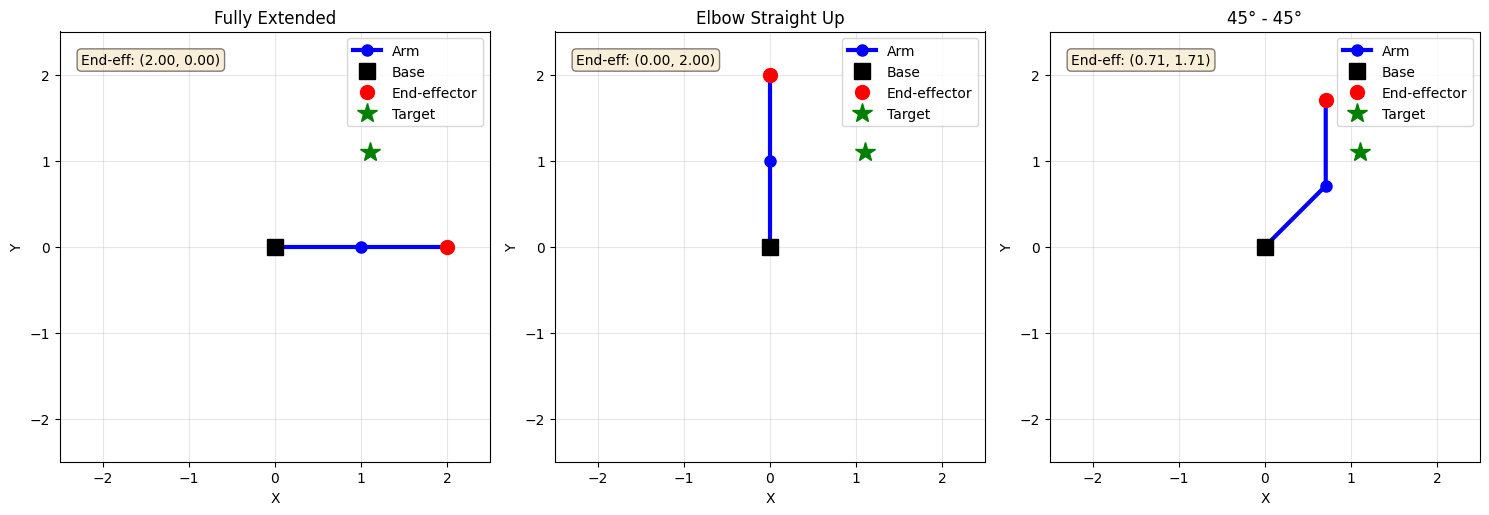

In [207]:
# Standard link lengths we'll use throughout
LENGTHS = np.array([1.0, 1.0])

# Example: Visualize different arm configurations
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
axes = axes.flatten()

# TODO: try more configurations
example_configs = [
    (np.array([0.0, 0.0]), "Fully Extended"),
    (np.array([np.pi/2, 0.0]), "Elbow Straight Up"),
    (np.array([np.pi/4, np.pi/4]), "45° - 45°"),
]

target = np.array([1.1, 1.1])
for i, (theta, title) in enumerate(example_configs):
    plot_arm(theta, LENGTHS, target=target, ax=axes[i], title=title)
    end_eff = forward_kinematics_numpy(theta, LENGTHS)
    axes[i].text(0.05, 0.95, f'End-eff: ({end_eff[0]:.2f}, {end_eff[1]:.2f})',
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

<div class="alert alert-info">
Q1: The robot arm has multiple solutions to reach the same point (elbow-up vs elbow-down configurations). Using the provided forward_kinematics function, find two different joint angle configurations θ = [θ₁, θ₂] that place the end-effector at approximately (1.1, 1.1). What does this tell you about the optimization landscape?
</div>

[1.09905036 1.09905036]


<Axes: title={'center': 'Robot Arm'}, xlabel='X', ylabel='Y'>

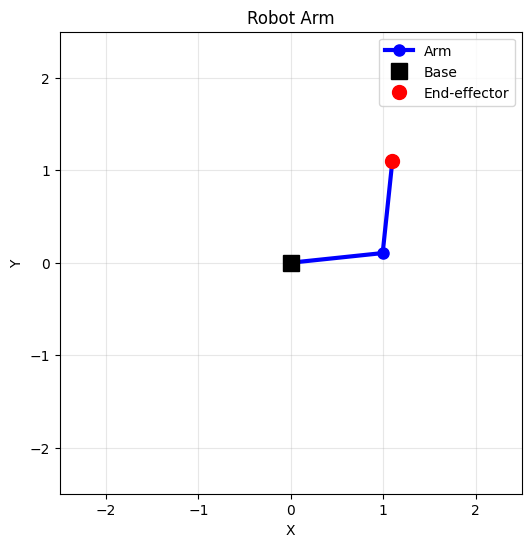

In [208]:
theta = np.array([np.pi/30, 13*np.pi/30])
print(forward_kinematics_numpy(theta, LENGTHS))
plot_arm(theta, LENGTHS)

Meilleurs thetas : [array([0.10471976, 1.36135682]), array([1.46607657, 4.92182849])]
A une distance 0.0013429956964627512 de [1.1 1.1]


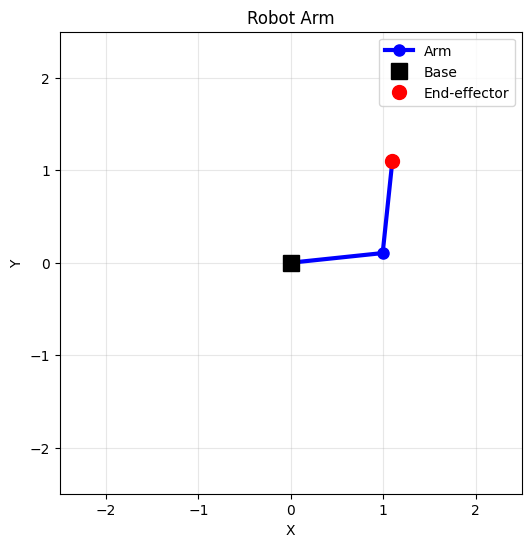

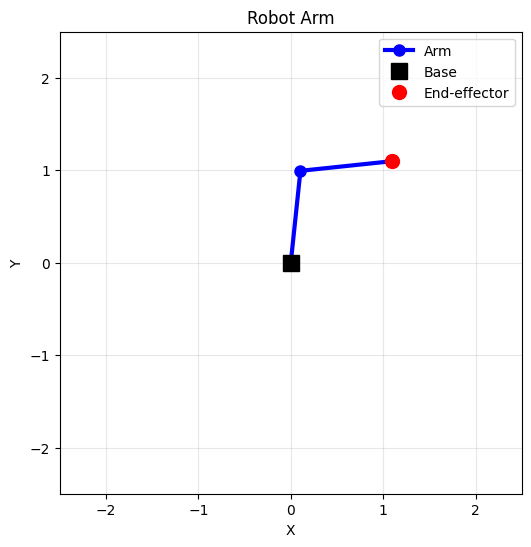

In [209]:
meilleurs_thetas = [np.array([0,0])]
meilleure_distance = np.inf
for i in range (361):
  for j in range (361):
    thetas = np.array([np.pi/180 * i, np.pi/180 * j])
    distance = np.linalg.norm(forward_kinematics_numpy(thetas, LENGTHS)-target)
    if distance < meilleure_distance :
      meilleurs_thetas = [thetas]
      meilleure_distance = distance
    elif distance == meilleure_distance and not np.equal(meilleurs_thetas[0],thetas).all() :
      meilleurs_thetas.append(thetas)
print(f"Meilleurs thetas : {meilleurs_thetas}")
print(f"A une distance {meilleure_distance} de {target}")

for thetas in meilleurs_thetas :
  plot_arm(thetas, LENGTHS)

Il existe plusieurs minimums donc l'espace des solutions n'est pas convexe.

## Part 1: Automatic Differentiation

Instead of guessing at the angles for a target, we will calculate them exactly. Use the provided JAX implementation to compute gradients of the loss function with respect to joint angles.

In [210]:
# Loss Functions
def loss_target_reaching(theta: jnp.ndarray, lengths: jnp.ndarray,
                        target: jnp.ndarray) -> float:
    """
    Loss for reaching a target position.

    L = ||end_effector(theta) - target||^2

    Parameters:
    -----------
    theta : jnp.ndarray, shape (2,)
        Joint angles
    lengths : jnp.ndarray, shape (2,)
        Link lengths
    target : jnp.ndarray, shape (2,)
        Target position

    Returns:
    --------
    loss : float
        Squared distance to target
    """
    end_effector = forward_kinematics_jax(theta, lengths)
    return jnp.sum((end_effector - target) ** 2)

In [211]:
# Create JIT-compiled versions for speed
loss_target_reaching_jit = jit(loss_target_reaching)
print(loss_target_reaching)
print(loss_target_reaching_jit)

<function loss_target_reaching at 0x7883fc0df7e0>
<PjitFunction of <function loss_target_reaching at 0x7883fc0df7e0>>


In [212]:
# Create gradient functions
grad_loss_target = jit(grad(loss_target_reaching, argnums=0))

In [213]:
# Test the loss functions
print("Testing loss functions...")
test_theta = jnp.array([0.5, 0.5])
test_lengths = jnp.array([1.0, 1.0])
test_target = jnp.array([1.0, 1.0])

loss_val = loss_target_reaching(test_theta, test_lengths, test_target)
print(f"Loss value: {loss_val:.4f}")

grad_val = grad_loss_target(test_theta, test_lengths, test_target)
print(f"Gradient: {grad_val}")

Testing loss functions...
Loss value: 0.2776
Gradient: [-0.19397666 -0.35651368]


<div class="alert alert-info">
Q2: Compute the gradient using JAX autodiff at $θ=[π/6, π/4]$
Then verify it matches a manual finite-difference approximation:

For finite differences, use:
  $∂L/∂θᵢ ≈ (L(θ + h*eᵢ) - L(θ - h*eᵢ)) / (2h)$
  where $eᵢ$ is the i-th unit vector and $h = 1e-5$
</div>

In [214]:
#Gradient computation with JAX
theta = jnp.array([jnp.pi/6, jnp.pi/4])
grad_val2 = grad_loss_target(theta, LENGTHS, target)
print(f"Gradient : {grad_val2}")

#Manual gradient computation
h = 1e-5
dL_dtheta1 = (loss_target_reaching(theta + jnp.array([h, 0.0]), LENGTHS, target) - loss_target_reaching(theta - jnp.array([h, 0.0]), LENGTHS, target)) / (2*h)
dL_dtheta2 = (loss_target_reaching(theta + jnp.array([0.0, h]), LENGTHS, target) - loss_target_reaching(theta - jnp.array([0.0, h]), LENGTHS, target)) / (2*h)
grad = [dL_dtheta1, dL_dtheta2]
print(f"Gradient : {grad}")

Gradient : [0.7503791  0.14142144]
Gradient : [Array(0.75250864, dtype=float32), Array(0.13932586, dtype=float32)]


Les résulats des 2 méthodes sont relativement proches.

<div class="alert alert-info">
Q3: Compare the computational time of evaluating the gradient using JAX autodiff versus evaluating just the forward pass (loss calculation only). Run each 1000 times and report the ratio. What does this tell you about the computational overhead of automatic differentiation?</div>

In [215]:
n_runs = 1000

# Time for the loss function
start_time_loss = time.time()
for _ in range(n_runs):
    loss_target_reaching_jit(theta, LENGTHS, target)
end_time_loss = time.time()
time_loss = end_time_loss - start_time_loss

print(f"Time for loss functin : {time_loss:.6f} seconds")

# Time for the gradient
start_time_grad = time.time()
for _ in range(n_runs):
    grad_loss_target(theta, LENGTHS, target)
end_time_grad = time.time()
time_grad = end_time_grad - start_time_grad

print(f"Time for gradient : {time_grad:.6f} seconds")


Time for loss functin : 0.111814 seconds
Time for gradient : 0.031113 seconds


Il est plus rapide de faire de l'autodiff directement que de simplement calculer la loss function.

## Part 2: Gradient Descent

Gradient Descent (GD) is the foundational optimization algorithm that iteratively moves parameters in the direction of steepest descent:
$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$

While conceptually simple, GD can be sensitive to the learning rate $η$ and may struggle with saddle points or narrow valleys in the loss landscape where the gradient direction changes rapidly.

For this exercise, implement basic gradient descent to move the robot arm to a target position.

In [216]:
def gradient_descent(theta_init: np.ndarray,
                     target: np.ndarray,
                     lengths: np.ndarray,
                     learning_rate: float = 0.01,
                     n_iterations: int = 500,
                     lambda_obs: float = 10.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)


    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))

    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))

    # Optimization loop
    for i in range(n_iterations):
        # TODO: Compute gradient
        gradient =  grad_loss_target(theta, lengths, target)

        # TODO: Update theta using gradient descent rule
        theta = theta - learning_rate * gradient

        # Store history
        theta_history[i + 1] = np.array(theta)
        loss_history[i + 1] = float(loss_fn(theta))
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))

    return theta_history, loss_history, ee_trajectory

<div class="alert alert-info">
Q4: Run GD with learning rates $η = [0.001, 0.01, 0.1, 0.5, 1.0]$ for 500 iterations each, starting from $θ₀ = [0.1, 0.1]$ targeting (0.5, 1.5). Plot the loss curves. At what learning rate do you observe divergence? Explain what's happening in terms of the gradient descent update rule.
</div>

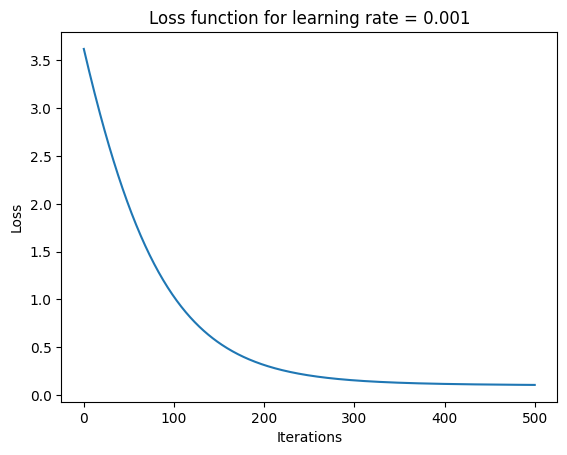

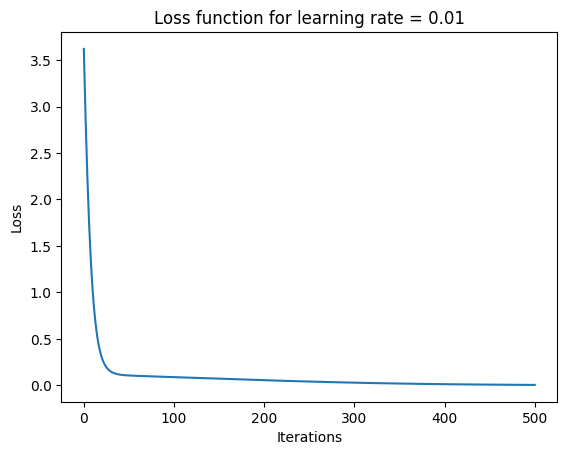

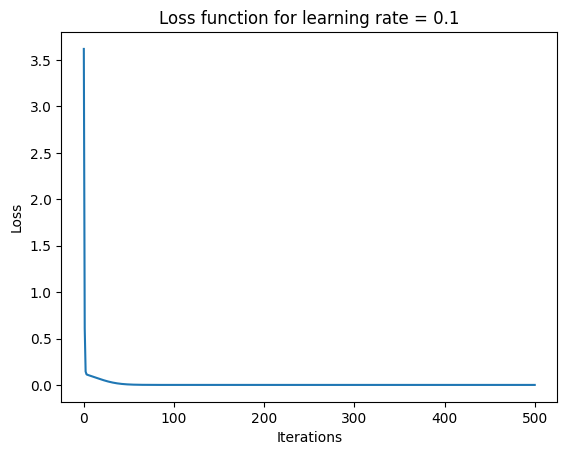

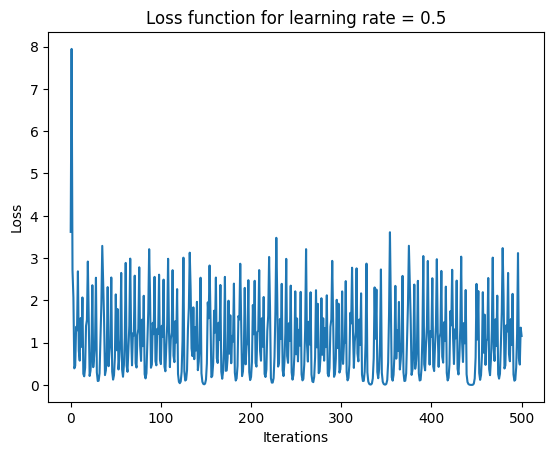

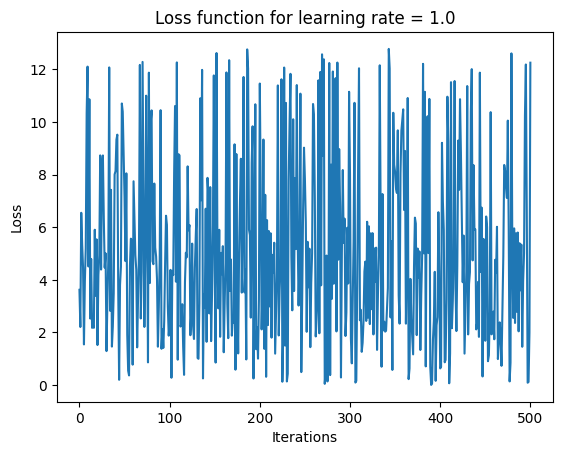

In [217]:
# Parameters
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
n_iterations = 500
theta_init = np.array([0.1, 0.1])
target = np.array([0.5, 1.5])


# Computation & plot
for l_rate in learning_rates :
  history = gradient_descent(theta_init, target, LENGTHS, l_rate, n_iterations)
  theta_history = history[0]
  loss_history = history[1]
  ee_trajectory = history[2]
  iterations = np.arange(n_iterations + 1)
  plt.title(f'Loss function for learning rate = {l_rate}')
  plt.plot(iterations, loss_history)
  plt.xlabel('Iterations')
  plt.ylabel('Loss')
  plt.show()

Il y a divergence à partir d'un learning_rate=0.5. Concrètement, l'algorithme fait des pas trop important pour converger vers une solution.

<div class="alert alert-info">
Q5: For $η = 0.01$, plot the end-effector trajectory in 2D space (not the loss, but the actual path the end-effector takes). Does it take the most direct path to the target? Why or why not? (Hint: think about parameter space vs task space)
</div>

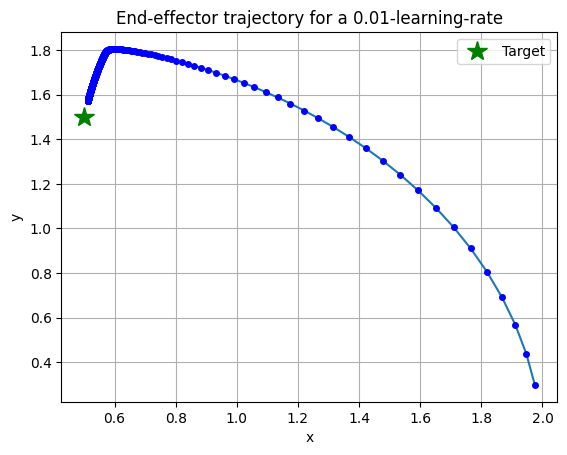

Final point : [0.51189065 1.56924427]


In [218]:
ee_trajectory = gradient_descent(theta_init, target, LENGTHS, 0.01, n_iterations)[2]

plt.title(f'End-effector trajectory for a 0.01-learning-rate')
plt.plot(ee_trajectory[:,0], ee_trajectory[:,1])
plt.plot(ee_trajectory[:,0], ee_trajectory[:,1], 'bo', markersize=4)
plt.plot(target[0], target[1], 'g*', markersize=15, label='Target')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()
print(f"Final point : {ee_trajectory[-1]}")


La trajectoire ne trace pas une ligne droite vers l'objectif car avec la descente de gradient, elle suit une vallée de l'espace des solutions.

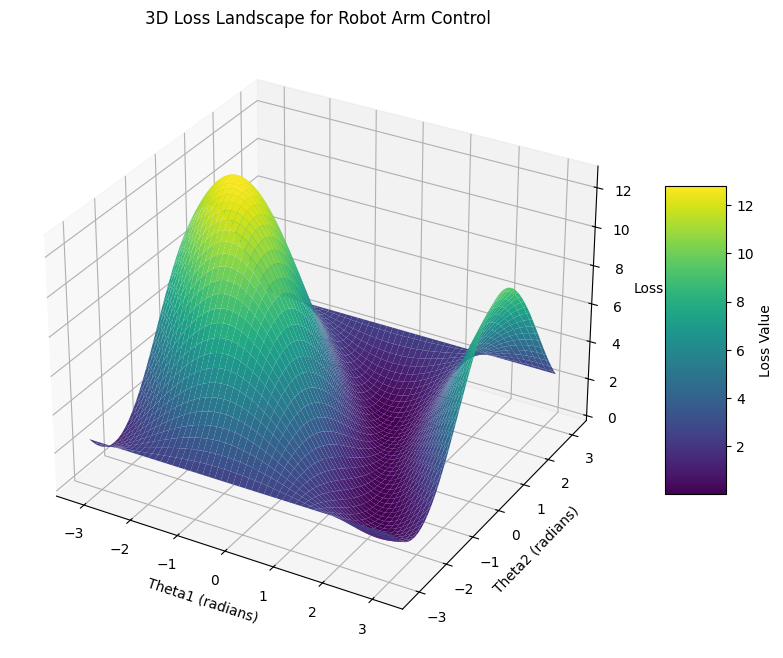

In [219]:
#Generated with AI
from mpl_toolkits.mplot3d import Axes3D

# Define the range for theta1 and theta2
theta1_range = np.linspace(-np.pi, np.pi, 100)
theta2_range = np.linspace(-np.pi, np.pi, 100)

# Create a meshgrid for theta1 and theta2
Theta1, Theta2 = np.meshgrid(theta1_range, theta2_range)

# Initialize a Z array to store loss values
Loss = np.zeros(Theta1.shape)

# Target and lengths from Q4
target_q4 = np.array([0.5, 1.5])
lengths_q4 = LENGTHS # Assuming LENGTHS is defined globally

# Calculate the loss for each combination of theta1 and theta2
for i in range(Theta1.shape[0]):
    for j in range(Theta1.shape[1]):
        current_theta = jnp.array([Theta1[i, j], Theta2[i, j]])
        Loss[i, j] = loss_target_reaching(current_theta, lengths_q4, target_q4)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(Theta1, Theta2, Loss, cmap='viridis')

# Add labels and title
ax.set_xlabel('Theta1 (radians)')
ax.set_ylabel('Theta2 (radians)')
ax.set_zlabel('Loss')
ax.set_title('3D Loss Landscape for Robot Arm Control')

# Add a color bar for the loss values
fig.colorbar(surface, shrink=0.5, aspect=5, label='Loss Value')

plt.show()

## 2.2: SGD with Momentum

Momentum adds "inertia" to gradient descent by accumulating a velocity vector that combines the current gradient with previous gradients: $v_t = \beta v_{t-1} + \nabla L(\theta_t)$
, then $\theta_{t+1} = \theta_t - \eta v_t$. This helps the optimizer build up speed in consistent directions and dampens oscillations in directions where gradients frequently change sign, allowing it to better navigate ravines and escape shallow local minima.


For this exercise, implement momentum-based gradient descent using the update rules:

$v_t = βv_{t-1} + ∇L(θ_t)$

$θ_{t+1} = θ_t - ηv_t$

<div class="alert alert-info">
Q6: Compare GD vs Momentum ($β=0.9$) on the same task ($η=0.01$, target (0.5, 1.5)). Plot both the loss curves and the end-effector trajectories side-by-side. Describe one specific, concrete difference in how the arm moves with momentum versus without.
</div>


In [220]:
def gradient_descent_momentum(theta_init: np.ndarray,
                     target: np.ndarray,
                     lengths: np.ndarray,
                     velocity_init: np.ndarray,
                     learning_rate: float = 0.01,
                     n_iterations: int = 500,
                     lambda_obs: float = 10.0,
                     beta: float = 0.9) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    velocity = jnp.array(velocity_init)

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    velocity_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))

    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))
    velocity_history[0] = np.array(velocity)

    # Optimization loop
    for i in range(n_iterations):
        # Compute gradient
        gradient =  grad_loss_target(theta, lengths, target)

        # Compute velocity
        velocity = beta * velocity + gradient

        # TODO: Update theta using gradient descent rule
        theta = theta - learning_rate * velocity

        # Store history
        theta_history[i + 1] = np.array(theta)
        loss_history[i + 1] = float(loss_fn(theta))
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
        velocity_history[i + 1] = np.array(velocity)
    return theta_history, loss_history, ee_trajectory, velocity_history

In [221]:
velocity_init = np.zeros(2)

normal_history = gradient_descent(theta_init, target, LENGTHS, 0.01, n_iterations)
momentum_history = gradient_descent_momentum(theta_init, target, LENGTHS, velocity_init, 0.01, n_iterations, 0.9)

Final point with normal GD : [0.51189065 1.56924427]
Final point with momentum GD: [0.49999982 1.49999976]


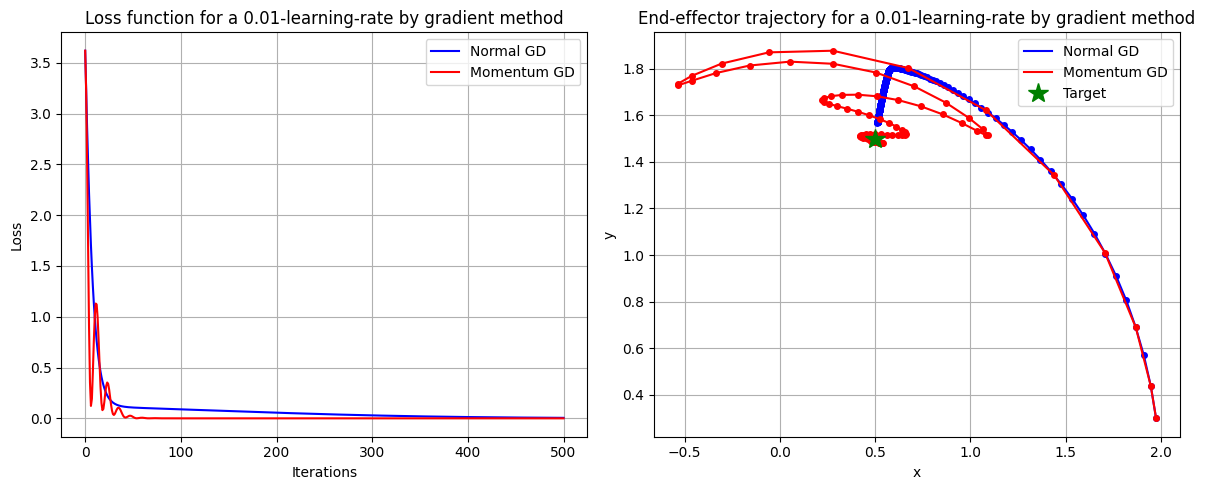

In [222]:
normal_ee_trajectory = normal_history[2]
momentum_ee_trajectory = momentum_history[2]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.title(f'End-effector trajectory for a 0.01-learning-rate by gradient method')
plt.plot(normal_ee_trajectory[:,0], normal_ee_trajectory[:,1], 'b', label='Normal GD')
plt.plot(normal_ee_trajectory[:,0], normal_ee_trajectory[:,1], 'bo', markersize=4)
plt.plot(momentum_ee_trajectory[:,0], momentum_ee_trajectory[:,1], 'r', label='Momentum GD')
plt.plot(momentum_ee_trajectory[:,0], momentum_ee_trajectory[:,1], 'ro', markersize=4)
plt.plot(target[0], target[1], 'g*', markersize=15, label='Target')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
print(f"Final point with normal GD : {normal_ee_trajectory[-1]}")
print(f"Final point with momentum GD: {momentum_ee_trajectory[-1]}")

normal_loss_history = normal_history[1]
momentum_loss_history = momentum_history[1]


iterations = np.arange(n_iterations + 1)

plt.subplot(1, 2, 1)
plt.title(f'Loss function for a 0.01-learning-rate by gradient method')
plt.plot(iterations, normal_loss_history, 'b', label='Normal GD')
plt.plot(iterations, momentum_loss_history, 'r', label='Momentum GD')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


Pour la descente de gradient avec momentum, le bras accélère lorsqu'il se rapproche de sa cible puis ralentit lorsqu'il s'en éloigne là ou sans ce momentum, il ne fait que déccélérer en se rapprochent de son objectif. Dans le premier cas, cela crée des oscillations avant d'atteindre son but mais cela accélère grandement le processus.

<div class="alert alert-info">
Q7: Track and plot the magnitude of the velocity vector $||v_t||$ over iterations for the momentum optimizer. What happens to this magnitude as the arm approaches the target? Explain why this behavior occurs.
</div>

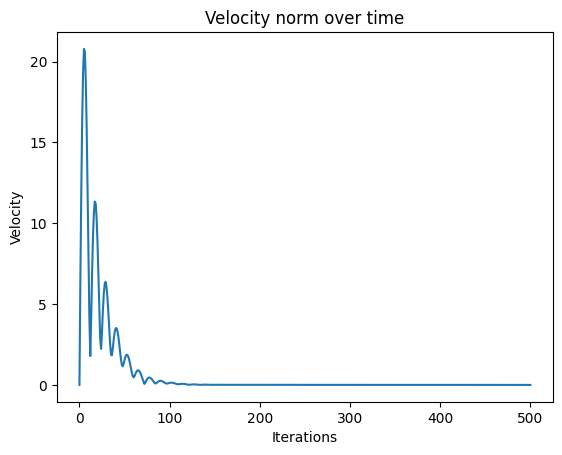

In [223]:
momentum_velocity_history = np.sum(np.abs(momentum_history[3])**2,axis=-1)**(1./2)
plt.title(f'Velocity norm over time')
plt.plot(iterations, momentum_velocity_history)
plt.xlabel('Iterations')
plt.ylabel('Velocity')
plt.show()





Tant que le bras se rapproche de sa cible, le bras accélère. Cependant au moment de changer de direction ou d'atteindre son objectif, le bras est emporté dans son élan et le dépasse. Il ralentit alors jusqu'à pouvoir "faire demi-tour" de direction. Le phénomène se répète et créé des oscillations.

## 2.3: Adam Optimizer

Adam (Adaptive Moment Estimation) combines ideas from momentum and adaptive learning rates by maintaining both a moving average of gradients (first moment $m_t$) and a moving average of squared gradients (second moment $v_t$).

By dividing the update by $\sqrt{v_t}$ Adam automatically adjusts the effective learning rate for each parameter based on the history of gradient magnitudes—parameters with large, consistent gradients get smaller effective steps, while parameters with small or noisy gradients get larger effective steps, making it particularly robust across different types of loss landscapes.

For this exercise, extend your Momentum SGD to include the second moment, following this update:

Update rules:
$
\begin{align}
g_t &= \nabla L(\theta_t) \\
m_t &= \beta_1 m_{t-1} + (1 - \beta_1) g_t \\
v_t &= \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \\
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t} \\
\theta_{t+1} &= \theta_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align}
$

<div class="alert alert-info">
Q8: Start the arm at $θ = [2.5, -2.0]$ trying to reach target ($0.8, 0.8$). Compare how many iterations GD ($η=0.01$), Momentum ($β=0.9, η=0.01$), and Adam (default parameters) each need to get within distance $0.01$ of the target. Report the iteration counts and explain the ranking.
</div>

In [224]:
def gradient_descent_adam(theta_init: np.ndarray,
                     target: np.ndarray,
                     lengths: np.ndarray,
                     first_moment_init : np.ndarray,
                     second_moment_init: np.ndarray,
                     learning_rate: float = 0.01,
                     n_iterations: int = 500,
                     lambda_obs: float = 10.0,
                     beta_1: float = 0.9,
                     beta_2: float = 0.999,
                     epsilon: float = 1e-5) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    second_moment = jnp.array(second_moment_init)
    first_moment = jnp.array(first_moment_init)


    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)
    grad_fn = grad_loss_target

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    first_moment_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))
    second_moment_history = np.zeros((n_iterations + 1, 2))

    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))
    second_moment_history[0] = np.array(second_moment)
    first_moment_history[0] = np.array(first_moment)


    # Optimization loop
    for i in range(n_iterations):
        # Compute gradient
        gradient =  grad_loss_target(theta, lengths, target)

        # Compute first_moment
        first_moment = beta_1 * first_moment + (1-beta_1) * gradient

        # Compute second_moment
        second_moment = beta_2 * second_moment + (1-beta_2) * gradient**2

        # Update theta using gradient descent rule
        # Correct bias for first and second moments
        first_moment_corrected = first_moment / (1 - beta_1**(i + 1) )
        second_moment_corrected = second_moment / (1 - beta_2**(i + 1))
        theta = theta - learning_rate * first_moment_corrected / (jnp.sqrt(second_moment_corrected) + epsilon)

        # Store history
        theta_history[i + 1] = np.array(theta)
        loss_history[i + 1] = float(loss_fn(theta))
        ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
        second_moment_history[i + 1] = np.array(second_moment_corrected)
        first_moment_history[i+1] = np.array(first_moment_corrected)
    return theta_history, loss_history, ee_trajectory, first_moment_history, second_moment_history

In [225]:
# Parameters

#theta_init = np.array([0.1, 0.1])
#target = np.array([0.5, 1.5])
theta_init = np.array([2.5, -2])
target = np.array([0.8, 0.8])
first_moment_init = np.zeros(2)
second_moment_init = np.zeros(2)
learning_rate = 0.01
n_iterations = 500
epsilon = 1e-8
beta = 0.9

normal_history = gradient_descent(theta_init, target, LENGTHS, learning_rate, n_iterations)
momentum_history = gradient_descent_momentum(theta_init, target, LENGTHS, first_moment_init, learning_rate, n_iterations, beta=beta)
adam_history = gradient_descent_adam(theta_init, target, LENGTHS, first_moment_init, second_moment_init, learning_rate, n_iterations, beta_1=beta, beta_2=beta, epsilon=epsilon)



Final point with Normal GD : [0.79706341 0.7988025 ]
Final point with Momentum GD: [0.80000031 0.80000007]
Final point with Adam GD: [0.80014521 0.79957938]


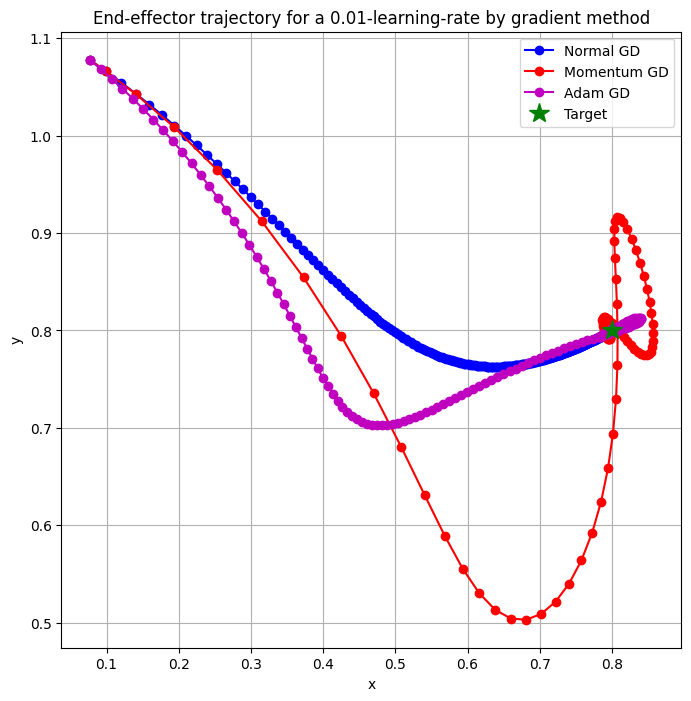

In [226]:
normal_ee_trajectory = normal_history[2]
momentum_ee_trajectory = momentum_history[2]
adam_ee_trajectory = adam_history[2]

plt.figure(figsize=(8, 8))
plt.title(f'End-effector trajectory for a 0.01-learning-rate by gradient method')
plt.plot(normal_ee_trajectory[:,0], normal_ee_trajectory[:,1], 'o-b', label='Normal GD')
plt.plot(momentum_ee_trajectory[:,0], momentum_ee_trajectory[:,1], 'o-r', label='Momentum GD')
plt.plot(adam_ee_trajectory[:,0], adam_ee_trajectory[:,1], 'o-m', label='Adam GD')
plt.plot(target[0], target[1], 'g*', markersize=15, label='Target')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
print(f"Final point with Normal GD : {normal_ee_trajectory[-1]}")
print(f"Final point with Momentum GD: {momentum_ee_trajectory[-1]}")
print(f"Final point with Adam GD: {adam_ee_trajectory[-1]}")



In [227]:
test_normal = True
test_momentum = True
test_adam = True


for k in range(n_iterations) :
  if test_normal:
    distance_to_target_normal = np.linalg.norm(normal_ee_trajectory[k]-target)
    if distance_to_target_normal < 0.01 :
      test_normal = False
      print(f"Target reached with GD after {k+1} iterations")
    elif k == n_iterations - 1 :
      print(f"Target not reached with GD after {n_iterations} iterations")
  if test_momentum:
    distance_to_target_momentum = np.linalg.norm(momentum_ee_trajectory[k]-target)
    if distance_to_target_momentum < 0.01 :
      test_momentum = False
      print(f"Target reached with Momentum GD after {k+1} iterations")
    elif k == n_iterations - 1 :
      print(f"Target not reached with Momentum GD after {n_iterations} iterations")
  if test_adam:
    distance_to_target_adam = np.linalg.norm(adam_ee_trajectory[k]-target)
    if distance_to_target_adam < 0.01 :
      test_adam = False
      print(f"Target reached with Adam GD after {k+1} iterations")
    elif k == n_iterations - 1 :
      print(f"Target not reached with Adam GD after {n_iterations} iterations")
  if not test_normal and not test_momentum and not test_adam :
    break

Target reached with Momentum GD after 28 iterations
Target reached with Adam GD after 81 iterations
Target reached with GD after 384 iterations


<div class="alert alert-info">
Q9: For the Adam optimizer on the same task, plot the effective per-parameter learning rate ($η_eff = η * m̂_t / (√v̂_t + ε)$) for both $θ₁$ and $θ₂$ over time. Do they receive the same effective learning rate throughout optimization? Explain why this adaptive behavior is useful.</div>

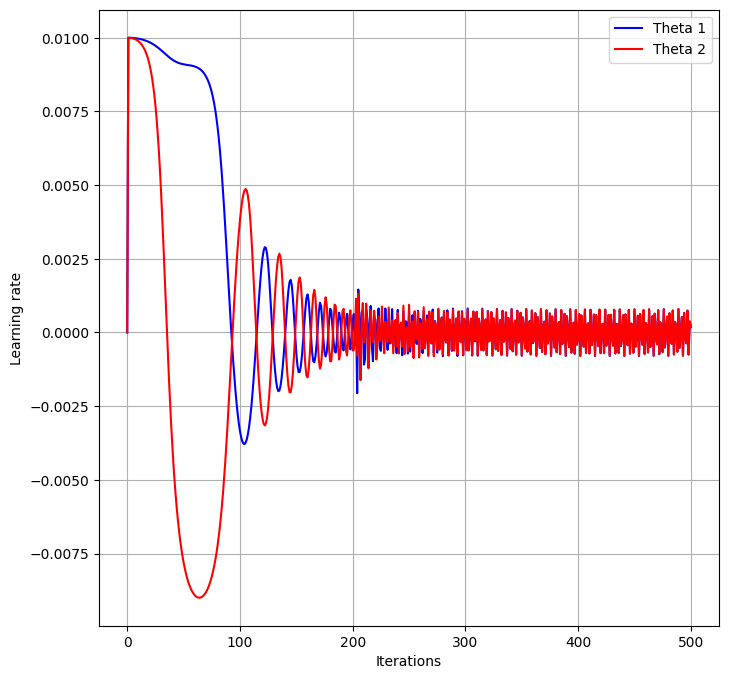

In [228]:
adam_first_moment_history, adam_second_moment_history = adam_history[3],adam_history[4]

effective_learning_rate_theta1 = learning_rate * adam_first_moment_history[:,0] / (np.sqrt(adam_second_moment_history[:,0]) + epsilon)
effective_learning_rate_theta2 = learning_rate * adam_first_moment_history[:,1] / (np.sqrt(adam_second_moment_history[:,1]) + epsilon)


plt.figure(figsize=(8, 8))
plt.title(f'')
plt.plot(np.arange(n_iterations+1), effective_learning_rate_theta1, 'b', label='Theta 1')
plt.plot(np.arange(n_iterations+1), effective_learning_rate_theta2, 'r', label='Theta 2')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Learning rate')
plt.grid(True)
plt.show()

Chaque theta a un taux de learning rate qui évolue en fonction de sa différentielle correspondante du gradiente. C'est un comportement interessant qui assure plus de robustesse.

## Part 3: Gradient-Free Optimization

For this exercise, implement a basic gradient-free algorithm, specifically an evolutionary strategy. Evolution Strategies are a class of gradient-free optimization algorithms inspired by natural evolution. Unlike gradient-based methods that require computing derivatives, ES samples multiple candidate solutions (a "population") around the current solution, evaluates their fitness (objective function value), and moves toward the direction indicated by the better-performing samples. Use the following rules for your ES:

For iteration $t$, with current parameter vector $\theta_t$:
$$
\begin{align}
\epsilon_i &\sim \mathcal{N}(0, I) \quad \text{for } i = 1, \ldots, N \\
\theta_i &= \theta_t + \sigma \epsilon_i \\
F_i &= -L(\theta_i) \quad \text{(fitness = negative loss)} \\
\theta_{t+1} &= \theta_t + \alpha \frac{1}{N} \sum_{i=1}^{N} F_i \epsilon_i
\end{align}
$$

where $N$ is the population size, $\sigma$ is the exploration noise (standard deviation), $\alpha$ is the learning rate, and $\epsilon_i$ are the perturbation vectors.

<div class="alert alert-info">
    Q10: Run this ES with population sizes $P = [10, 20, 50]$. For each, report: (a) does it reach the target successfully? (b) how many iterations does it take? (c) total number of function evaluations ($P$ × iterations). What trend do you observe with increasing population size?</div>

In [229]:
from jax import grad, jit

def evolutionary_strategy(population_size: int,
                          theta_init: np.ndarray,
                          lengths: np.ndarray,
                          target: np.ndarray,
                          n_iterations: int = 500,
                          learning_rate: float = 0.01,
                          exploration_noise: float = 0.01) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Convert to JAX arrays
    theta = jnp.array(theta_init)
    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)

    loss_fn = lambda th: loss_target_reaching(th, lengths_jax, target_jax)

    # Storage for history
    theta_history = np.zeros((n_iterations + 1, 2))
    loss_history = np.zeros(n_iterations + 1)
    ee_trajectory = np.zeros((n_iterations + 1, 2))


    # Initial values
    theta_history[0] = np.array(theta)
    loss_history[0] = float(loss_fn(theta))
    ee_trajectory[0] = np.array(forward_kinematics_jax(theta, lengths_jax))


    # Optimization loop
    for i in range(n_iterations):

      # Compute the perturbation vectors
      perturbation_vectors = np.array([np.random.normal(size = 2) for p in range(population_size)])

      # Compute fitness
      fitness = np.array([- loss_fn(theta + exploration_noise * k) for k in perturbation_vectors])

      # Update theta
      theta = theta + learning_rate * 1/population_size * np.sum(fitness[:, None] * perturbation_vectors, axis = 0)

      # Store history
      theta_history[i + 1] = np.array(theta)
      loss_history[i + 1] = float(loss_fn(theta))
      ee_trajectory[i + 1] = np.array(forward_kinematics_jax(theta, lengths_jax))
    return theta_history, loss_history, ee_trajectory

Final point : [0.07504052 1.41318464]
Final point : [0.06774855 1.3912499 ]
Final point : [0.16090399 1.47364998]


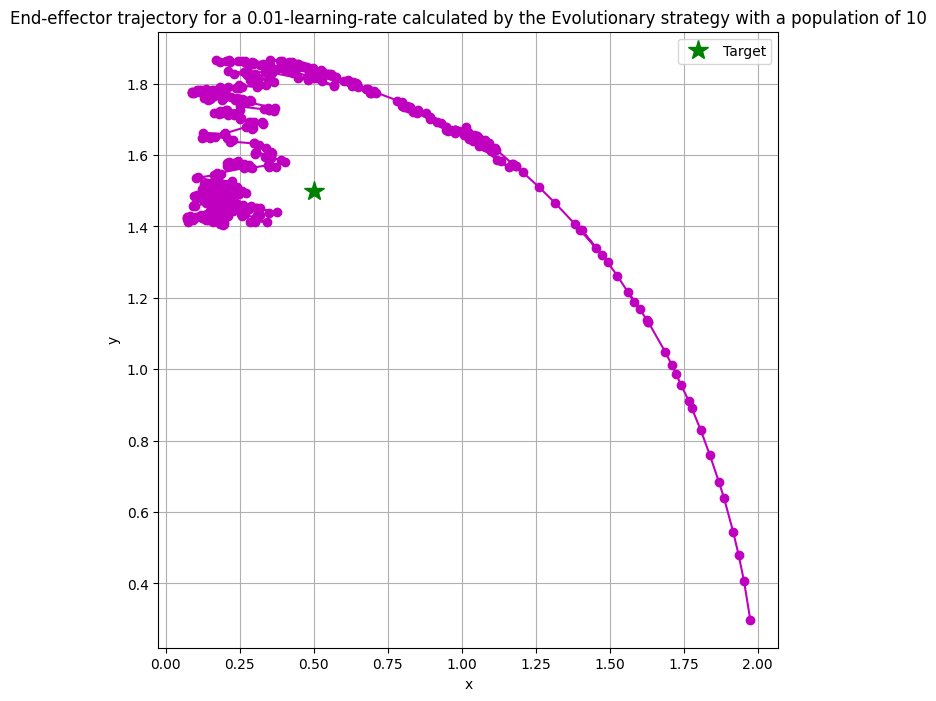

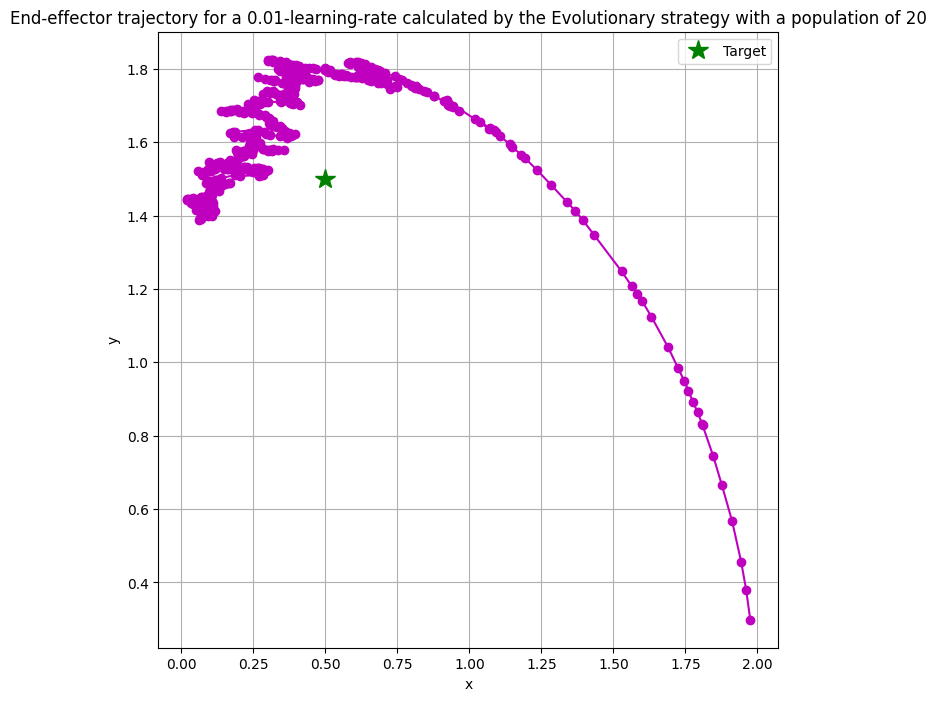

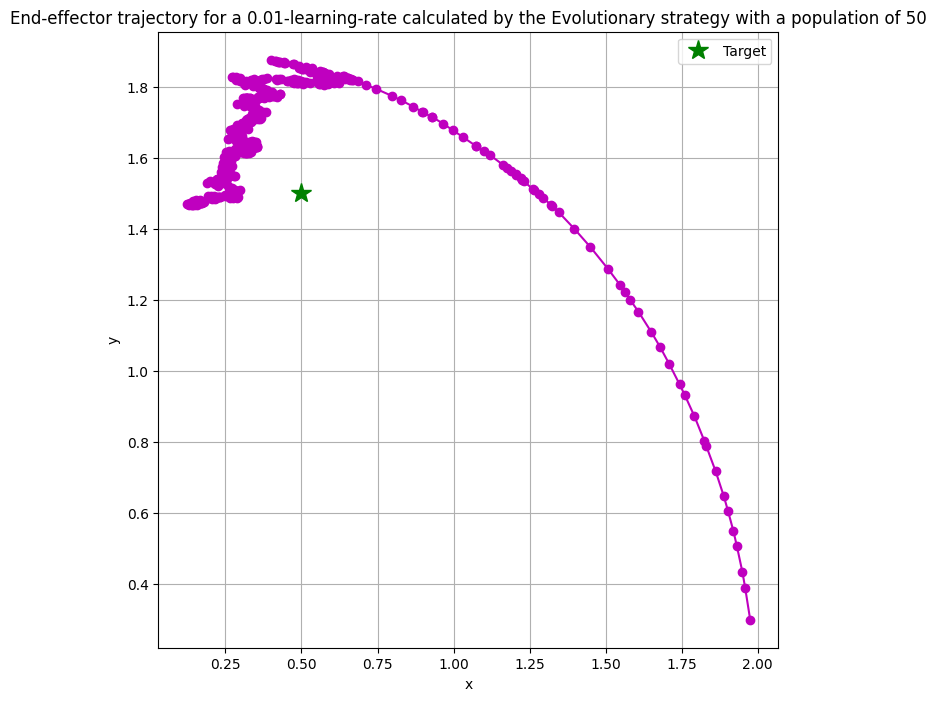

In [230]:
# Parameters
population_sizes = [10, 20, 50]
theta_init = np.array([0.1, 0.1])
target = np.array([0.5, 1.5])
learning_rate = 0.01
exploration_noise = 0.9
n_iterations = 500

for pop in population_sizes :
  evolutionary_history = evolutionary_strategy(population_size = pop, theta_init = theta_init, lengths = LENGTHS, target = target, n_iterations = n_iterations, learning_rate = learning_rate, exploration_noise = exploration_noise)

  evolutionary_ee_trajectory = evolutionary_history[2]

  plt.figure(figsize=(8, 8))
  plt.title(f'End-effector trajectory for a 0.01-learning-rate calculated by the Evolutionary strategy with a population of {pop}')
  plt.plot(evolutionary_ee_trajectory[:,0], evolutionary_ee_trajectory[:,1], 'o-m')
  plt.plot(target[0], target[1], 'g*', markersize=15, label='Target')
  plt.legend()
  plt.xlabel('x')
  plt.ylabel('y')
  plt.grid(True)
  print(f"Final point : {evolutionary_ee_trajectory[-1]}")


Visiblement l'algorithme n'atteint pas son objectif quelque soit le nombre d'itérations ou la taille de la population. Bien qu'il s'agisse d'un algorithme plus simpliste, c'est un résultat qui paraît surprenant et décevant. Il y a certainement une erreur d'implémentation.

<div class="alert alert-info">
Q11: ES doesn't use gradients, so it evaluates the loss N times per iteration while SGD evaluates it once plus one gradient computation. For a successful run of each method, count total loss function evaluations. Which is more sample-efficient? Despite this, describe one scenario where ES might still be preferred over gradient-based methods.</div>

Il n'y a pas de réussite avec la stratégie évolutionnaire. Pour Adam et Momentum il y a autant d'appel au gradient à nombre d'itérations fixé donc c'est le nombre nécessaire pour atteindre l'objectif qui est important. La stratégie évolutionnaire peut être intéressant si le gradient est incalculable mais il ne faut pas avoir besoin d'être précis.

## Part 4: Trajectory Optimization - Optimizing Sequences

So far, we've only optimized the **final configuration** of the robot arm - finding joint angles that place the end-effector at the target. However, in real robotics, we often care about the **entire motion path**. A robot might reach the target, but if it does so with jerky, energy-intensive movements, the solution isn't practical.

In this section, you'll optimize a **trajectory** - a sequence of joint angles over time - to reach the target while minimizing energy consumption and ensuring smooth motion.

### Trajectory Representation

Instead of optimizing $\theta \in \mathbb{R}^2$, we now optimize:
$$\Theta = [\theta_0, \theta_1, \ldots, \theta_T] \in \mathbb{R}^{T \times 2}$$

where $T$ is the number of timesteps (e.g., $T=20$).

### Multi-Objective Loss Function

We balance three competing objectives:

$$L_{total}(\Theta) = L_{target} + \lambda_{energy} L_{energy} + \lambda_{smooth} L_{smooth}$$

where:
- **Target reaching**: $L_{target} = \|\text{pos}(\theta_T) - \text{target}\|^2$ (only final position matters)
- **Energy cost**: $L_{energy} = \sum_{t=1}^{T} \|\theta_t - \theta_{t-1}\|^2$ (penalize large joint movements)
- **Smoothness**: $L_{smooth} = \sum_{t=2}^{T} \|(\theta_t - \theta_{t-1}) - (\theta_{t-1} - \theta_{t-2})\|^2$ (penalize acceleration/jerkiness)

The hyperparameters $\lambda_{energy}$ and $\lambda_{smooth}$ control the trade-off between reaching the target quickly versus moving efficiently and smoothly.

In [231]:
# Trajectory Optimization Functions

def loss_trajectory(theta_sequence: jnp.ndarray,
                   lengths: jnp.ndarray,
                   target: jnp.ndarray,
                   lambda_energy: float = 0.1,
                   lambda_smooth: float = 0.05) -> float:
    """
    Loss for trajectory optimization.

    Parameters:
    -----------
    theta_sequence : jnp.ndarray, shape (T, 2)
        Sequence of joint angles over T timesteps
    lengths : jnp.ndarray, shape (2,)
        Link lengths
    target : jnp.ndarray, shape (2,)
        Target position
    lambda_energy : float
        Weight for energy cost
    lambda_smooth : float
        Weight for smoothness cost

    Returns:
    --------
    loss : float
        Total loss combining target reaching, energy, and smoothness
    """
    T = theta_sequence.shape[0]

    # Target reaching: only final position matters
    final_pos = forward_kinematics_jax(theta_sequence[-1], lengths)
    loss_target = jnp.sum((final_pos - target) ** 2)

    # Energy cost: sum of squared velocities (joint movements)
    velocities = theta_sequence[1:] - theta_sequence[:-1]  # Shape: (T-1, 2)
    loss_energy = jnp.sum(velocities ** 2)

    # Smoothness cost: sum of squared accelerations
    accelerations = velocities[1:] - velocities[:-1]  # Shape: (T-2, 2)
    loss_smooth = jnp.sum(accelerations ** 2)

    return loss_target + lambda_energy * loss_energy + lambda_smooth * loss_smooth


# Create gradient function for trajectory optimization
grad_loss_trajectory = jit(grad(loss_trajectory, argnums=0))

In [232]:
def plot_trajectory_sequence(theta_sequence: np.ndarray,
                             lengths: np.ndarray,
                             target: np.ndarray = None,
                             title: str = "Arm Trajectory Over Time"):
    """
    Visualize the robot arm at multiple points along the trajectory.

    Parameters:
    -----------
    theta_sequence : np.ndarray, shape (T, 2)
        Sequence of joint angles
    lengths : np.ndarray
        Link lengths
    target : np.ndarray, optional
        Target position
    title : str
        Plot title
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    T = len(theta_sequence)
    colors = plt.cm.viridis(np.linspace(0, 1, T))

    # Plot each arm configuration
    for t in range(0, T, max(1, T//10)):  # Show ~10 frames
        points = get_arm_points(theta_sequence[t], lengths)
        alpha = 0.3 + 0.7 * (t / T)  # Fade from transparent to opaque
        ax.plot(points[:, 0], points[:, 1], 'o-',
               color=colors[t], alpha=alpha, linewidth=2, markersize=4)

    # Plot final configuration more prominently
    points_final = get_arm_points(theta_sequence[-1], lengths)
    ax.plot(points_final[:, 0], points_final[:, 1], 'o-',
           color='red', linewidth=3, markersize=8, label='Final')

    # Plot end-effector trajectory
    ee_traj = np.array([forward_kinematics_numpy(theta_sequence[t], lengths)
                        for t in range(T)])
    ax.plot(ee_traj[:, 0], ee_traj[:, 1], 'b--',
           linewidth=2, alpha=0.5, label='End-effector path')

    # Plot target
    if target is not None:
        ax.plot(target[0], target[1], 'g*', markersize=20, label='Target')

    # Plot base
    ax.plot(0, 0, 'ks', markersize=12, label='Base')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.legend()

    return fig, ax

In [233]:
def analyze_trajectory_metrics(theta_sequence: np.ndarray):
    """
    Compute and print trajectory quality metrics.

    Parameters:
    -----------
    theta_sequence : np.ndarray, shape (T, 2)
        Sequence of joint angles
    """
    velocities = np.diff(theta_sequence, axis=0)
    accelerations = np.diff(velocities, axis=0)

    # Compute metrics
    total_movement = np.sum(np.abs(velocities))
    max_velocity = np.max(np.linalg.norm(velocities, axis=1))
    max_acceleration = np.max(np.linalg.norm(accelerations, axis=1))
    smoothness = np.sum(accelerations ** 2)  # Lower is smoother

    print("Trajectory Metrics:")
    print(f"  Total joint movement: {total_movement:.4f} radians")
    print(f"  Max velocity: {max_velocity:.4f} rad/timestep")
    print(f"  Max acceleration: {max_acceleration:.4f} rad/timestep²")
    print(f"  Smoothness cost: {smoothness:.4f} (lower is better)")

In [234]:
# Test trajectory optimization with gradient descent
def gradient_descent_trajectory(theta_init: np.ndarray,
                               target: np.ndarray,
                               lengths: np.ndarray,
                               T: int = 20,
                               learning_rate: float = 0.01,
                               n_iterations: int = 1000,
                               lambda_energy: float = 0.1,
                               lambda_smooth: float = 0.05):
    # Initialize trajectory: linear interpolation from init to a guess
    target_angles = theta_init + 0.5  # Simple guess for final angles
    theta_sequence = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ])

    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)

    loss_history = []

    for iteration in range(n_iterations):
        # Compute loss and gradient
        loss_val = loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                   lambda_energy, lambda_smooth)
        gradient = grad_loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                       lambda_energy, lambda_smooth)

        # Update trajectory
        theta_sequence = theta_sequence - learning_rate * gradient

        loss_history.append(float(loss_val))

        if iteration % 100 == 0:
            print(f"Iteration {iteration}: Loss = {loss_val:.6f}")

    return np.array(theta_sequence), np.array(loss_history)

In [235]:
# Example usage
print("="*60)
print("Testing Trajectory Optimization")
print("="*60)

theta_init = np.array([0.1, 0.1])
target = np.array([1.0, 1.5])
T = 20

print(f"\nOptimizing trajectory with T={T} timesteps")
print(f"Initial configuration: {theta_init}")
print(f"Target position: {target}\n")

theta_traj, loss_hist = gradient_descent_trajectory(
    theta_init, target, LENGTHS,
    T=T, learning_rate=0.01, n_iterations=1000,
    lambda_energy=0.1, lambda_smooth=0.05
)

Testing Trajectory Optimization

Optimizing trajectory with T=20 timesteps
Initial configuration: [0.1 0.1]
Target position: [1.  1.5]

Iteration 0: Loss = 0.037871
Iteration 100: Loss = 0.011086
Iteration 200: Loss = 0.009691
Iteration 300: Loss = 0.008755
Iteration 400: Loss = 0.008082
Iteration 500: Loss = 0.007578
Iteration 600: Loss = 0.007187
Iteration 700: Loss = 0.006876
Iteration 800: Loss = 0.006623
Iteration 900: Loss = 0.006412


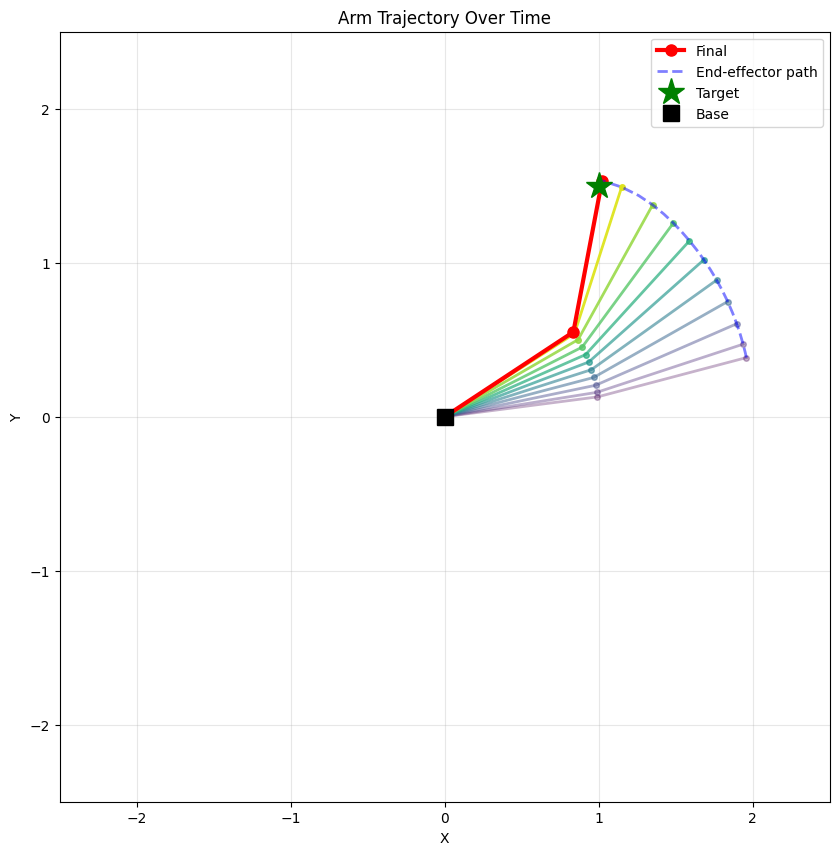

Trajectory Metrics:
  Total joint movement: 1.1252 radians
  Max velocity: 0.1116 rad/timestep
  Max acceleration: 0.0265 rad/timestep²
  Smoothness cost: 0.0019 (lower is better)


In [236]:
# Visualize results
#plot_loss_curve(loss_hist, "Trajectory Optimization Loss")
#plt.show()

plot_trajectory_sequence(theta_traj, LENGTHS, target)
plt.show()

analyze_trajectory_metrics(theta_traj)

<div class="alert alert-info">
Q12: Run trajectory optimization with three different energy weights: $\lambda_{energy} = [0.01, 0.1, 1.0]$ (keep $\lambda_{smooth}=0.05$ fixed). For each, visualize the resulting trajectory and report the total joint movement (sum of velocity magnitudes). How does increasing the energy penalty affect the motion? Does the arm still reach the target?
</div>

Iteration 0: Loss = 0.035503
Iteration 100: Loss = 0.007561
Iteration 200: Loss = 0.005755
Iteration 300: Loss = 0.004471
Iteration 400: Loss = 0.003555
Iteration 500: Loss = 0.002902
Iteration 600: Loss = 0.002436
Iteration 700: Loss = 0.002100
Iteration 800: Loss = 0.001854
Iteration 900: Loss = 0.001671


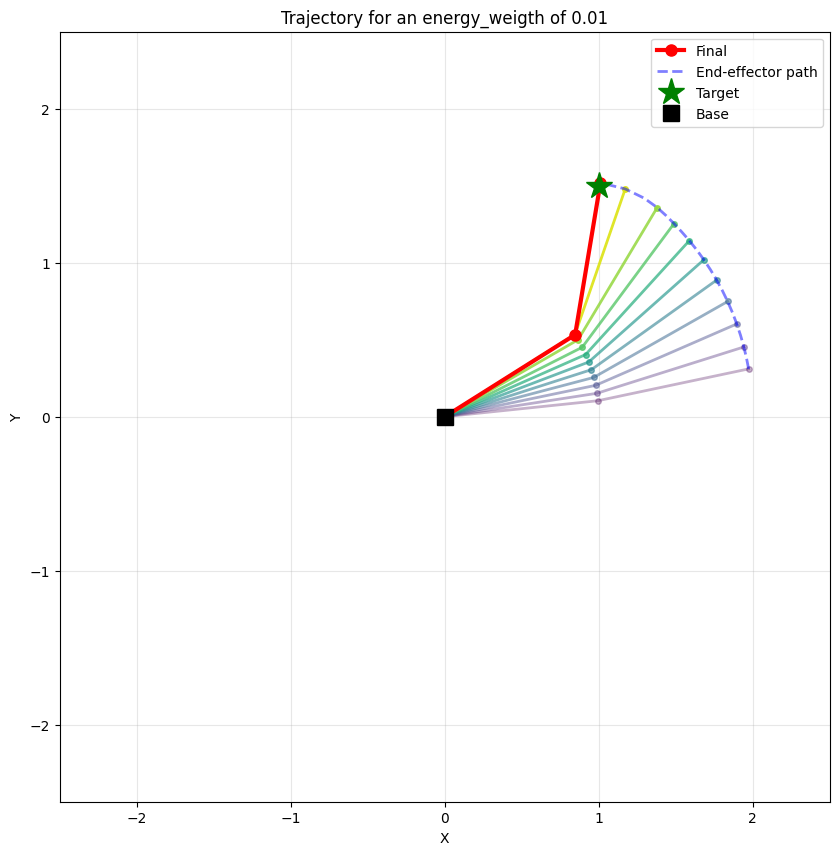

Trajectory Metrics:
  Total joint movement: 1.2012 radians
  Max velocity: 0.1691 rad/timestep
  Max acceleration: 0.0592 rad/timestep²
  Smoothness cost: 0.0079 (lower is better)

 ---- 

Iteration 0: Loss = 0.037871
Iteration 100: Loss = 0.011086
Iteration 200: Loss = 0.009691
Iteration 300: Loss = 0.008755
Iteration 400: Loss = 0.008082
Iteration 500: Loss = 0.007578
Iteration 600: Loss = 0.007187
Iteration 700: Loss = 0.006876
Iteration 800: Loss = 0.006623
Iteration 900: Loss = 0.006412


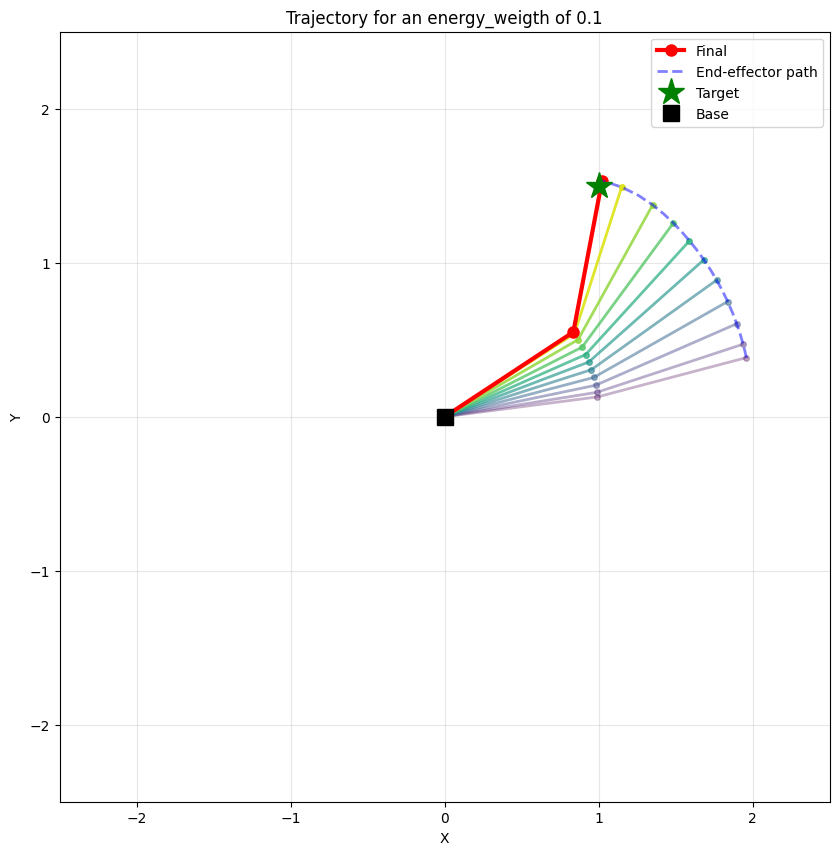

Trajectory Metrics:
  Total joint movement: 1.1252 radians
  Max velocity: 0.1116 rad/timestep
  Max acceleration: 0.0265 rad/timestep²
  Smoothness cost: 0.0019 (lower is better)

 ---- 

Iteration 0: Loss = 0.061556
Iteration 100: Loss = 0.039454
Iteration 200: Loss = 0.037582
Iteration 300: Loss = 0.036278
Iteration 400: Loss = 0.035221
Iteration 500: Loss = 0.034304
Iteration 600: Loss = 0.033473
Iteration 700: Loss = 0.032701
Iteration 800: Loss = 0.031970
Iteration 900: Loss = 0.031271


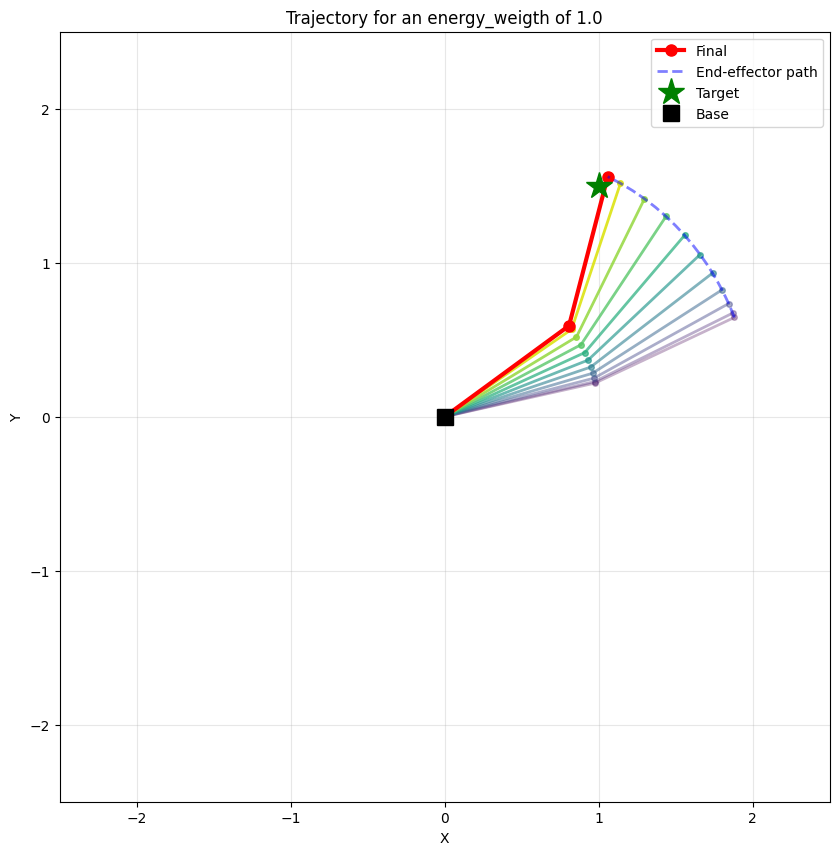

Trajectory Metrics:
  Total joint movement: 0.8764 radians
  Max velocity: 0.0494 rad/timestep
  Max acceleration: 0.0044 rad/timestep²
  Smoothness cost: 0.0001 (lower is better)

 ---- 



In [237]:
# Parameters
energy_weigths = [0.01, 0.1, 1.0]

for k in energy_weigths :
  theta_traj, loss_hist = gradient_descent_trajectory(
      theta_init, target, LENGTHS,
      T=T, learning_rate=0.01, n_iterations=1000,
      lambda_energy=k, lambda_smooth=0.05)

  plot_trajectory_sequence(theta_traj, LENGTHS, target)
  plt.title(f"Trajectory for an energy_weigth of {k}")
  plt.show()

  analyze_trajectory_metrics(theta_traj)
  print("\n ---- \n")

Augmenter la pénalité liée à l'énergie ralentit le mouvement. Cela a pour effet de le rendre plus lisse et moins brusque. Avec un poids sur l'énergie de 1.0, le bras n'atteind plus sa cible.

<div class="alert alert-info">
Q13: Compare trajectory optimization using SGD with Momentum vs Adam. Use $T=20$, $\lambda_{energy}=0.1$, $\lambda_{smooth}=0.05$. Which converges faster? Plot both trajectories side-by-side. Do they find qualitatively different solutions (different motion strategies)?
</div>

In [238]:
def gradient_descent_trajectory_momentum(theta_init: np.ndarray,
                               target: np.ndarray,
                               lengths: np.ndarray,
                               T: int = 20,
                               learning_rate: float = 0.01,
                               n_iterations: int = 1000,
                               lambda_energy: float = 0.1,
                               lambda_smooth: float = 0.05,
                               beta = 0.9):
    # Initialize trajectory: linear interpolation from init to a guess
    target_angles = theta_init + 0.5  # Simple guess for final angles
    theta_sequence = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ])

    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    velocity = jnp.zeros_like(theta_sequence)
    loss_history = []

    for iteration in range(n_iterations):
        # Compute loss and gradient
        loss_val = loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                   lambda_energy, lambda_smooth)
        gradient = grad_loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                       lambda_energy, lambda_smooth)

        # Update trajectory

        velocity = beta * velocity + gradient

        updated_theta_sequence = theta_sequence - learning_rate * velocity
        theta_sequence = theta_sequence.at[1:].set(updated_theta_sequence[1:])


        loss_history.append(float(loss_val))

        if iteration % 100 == 0:
            print(f"Iteration {iteration}: Loss = {loss_val:.6f}")

    return np.array(theta_sequence), np.array(loss_history)

Iteration 0: Loss = 0.037871
Iteration 100: Loss = 0.006526
Iteration 200: Loss = 0.005651
Iteration 300: Loss = 0.005296
Iteration 400: Loss = 0.005091
Iteration 500: Loss = 0.004953
Iteration 600: Loss = 0.004853
Iteration 700: Loss = 0.004775
Iteration 800: Loss = 0.004713
Iteration 900: Loss = 0.004662


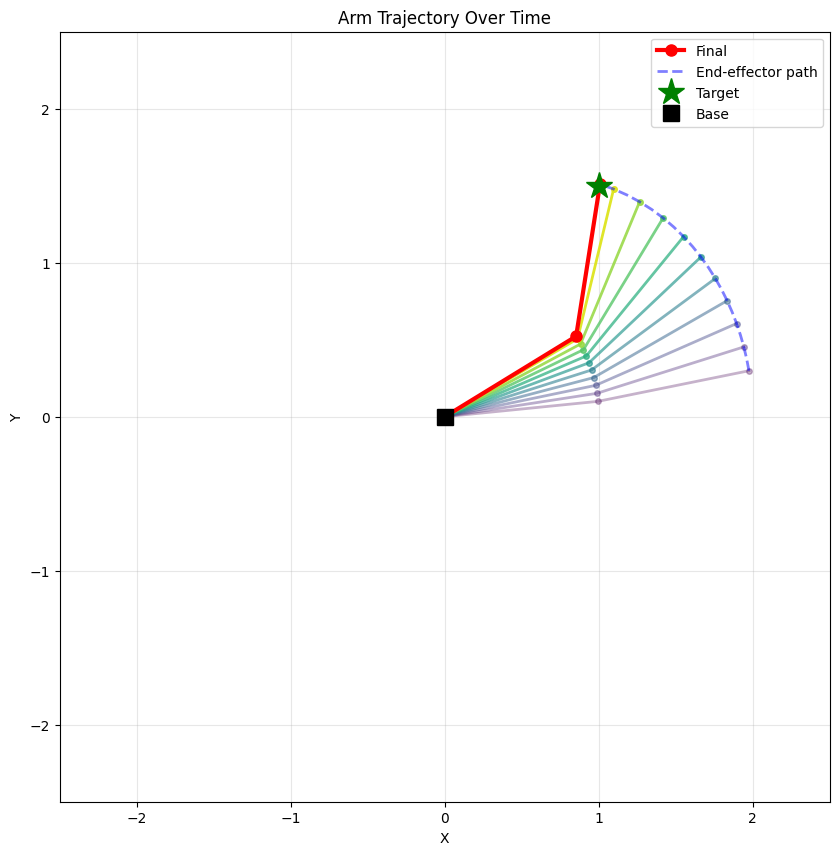

Trajectory Metrics:
  Total joint movement: 1.2150 radians
  Max velocity: 0.0645 rad/timestep
  Max acceleration: 0.0035 rad/timestep²
  Smoothness cost: 0.0001 (lower is better)


In [239]:
theta_traj, loss_hist = gradient_descent_trajectory_momentum(
    theta_init, target, LENGTHS,
    T=T, learning_rate=0.01, n_iterations=1000,
    lambda_energy=0.1, lambda_smooth=0.05, beta=0.9
)

plot_trajectory_sequence(theta_traj, LENGTHS, target)
plt.show()

analyze_trajectory_metrics(theta_traj)

In [240]:
def gradient_descent_trajectory_adam(theta_init: np.ndarray,
                               target: np.ndarray,
                               lengths: np.ndarray,
                               T: int = 20,
                               learning_rate: float = 0.01,
                               n_iterations: int = 1000,
                               lambda_energy: float = 0.1,
                               lambda_smooth: float = 0.05,
                               beta_1 = 0.9,
                               beta_2 = 0.9,
                               epsilon = 1e-8):
    # Initialize trajectory: linear interpolation from init to a guess
    target_angles = theta_init + 0.5  # Simple guess for final angles
    theta_sequence = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ])

    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)
    first_moment = jnp.zeros_like(theta_sequence)
    second_moment = jnp.zeros_like(theta_sequence)

    loss_history = []

    for iteration in range(n_iterations):
        # Compute loss and gradient
        loss_val = loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                   lambda_energy, lambda_smooth)
        gradient = grad_loss_trajectory(theta_sequence, lengths_jax, target_jax,
                                       lambda_energy, lambda_smooth)

        # Update trajectory

        # Compute first_moment
        first_moment = beta_1 * first_moment + (1-beta_1) * gradient

        # Compute second_momenten
        second_moment = beta_2 * second_moment + (1-beta_2) * gradient**2

        # Compute corrected moment
        first_moment_corrected = first_moment / (1 - beta_1**(iteration + 1) )
        second_moment_corrected = second_moment / (1 - beta_2**(iteration + 1))

        # Apply update, keeping the first element fixed
        updated_theta_sequence = theta_sequence - learning_rate *  first_moment_corrected / (jnp.sqrt(second_moment_corrected) + epsilon)
        theta_sequence = theta_sequence.at[1:].set(updated_theta_sequence[1:])

        loss_history.append(float(loss_val))

        if iteration % 100 == 0:
            print(f"Adam Iteration {iteration}: Loss = {loss_val:.6f}")

    return np.array(theta_sequence), np.array(loss_history)

Adam Iteration 0: Loss = 0.037871
Adam Iteration 100: Loss = 0.004290
Adam Iteration 200: Loss = 0.004287
Adam Iteration 300: Loss = 0.004282
Adam Iteration 400: Loss = 0.004283
Adam Iteration 500: Loss = 0.004282
Adam Iteration 600: Loss = 0.004283
Adam Iteration 700: Loss = 0.004282
Adam Iteration 800: Loss = 0.004281
Adam Iteration 900: Loss = 0.004283


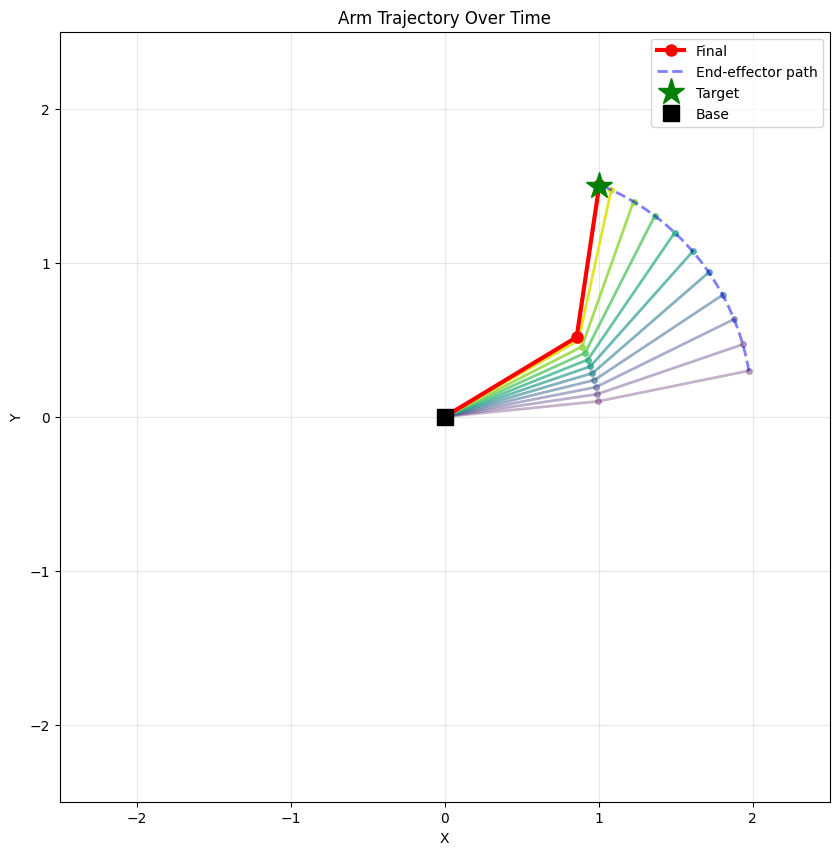

Trajectory Metrics:
  Total joint movement: 1.2227 radians
  Max velocity: 0.0481 rad/timestep
  Max acceleration: 0.0046 rad/timestep²
  Smoothness cost: 0.0001 (lower is better)


In [241]:
theta_init = np.array([0.1, 0.1])
target = np.array([1.0, 1.5])
T = 20

theta_traj, loss_hist = gradient_descent_trajectory_adam(
    theta_init, target, LENGTHS,
    T=T, learning_rate=0.01, n_iterations=1000,
    lambda_energy=0.1, lambda_smooth=0.05, beta_1=0.9, beta_2=0.9, epsilon = 1e-8
)

plot_trajectory_sequence(theta_traj, LENGTHS, target)
plt.show()

analyze_trajectory_metrics(theta_traj)


<div class="alert alert-info">
Q14: The trajectory optimization problem has $T \times 2$ parameters (40 parameters for $T=20$). This is similar to optimizing a small neural network. Based on your experiments, which optimizer (GD, Momentum, Adam) would you recommend for optimizing trajectories? How might your answer change if $T=100$ (200 parameters)?
</div>

L'optimiseur Adam semble le plus à même de représenter des problèms d'une certaine complexité. Dans le cadre du calcul de l'optimum de trajectoire, on se rend compte qu'il converge plus rapidement. Avec T=100 c'est donc le même choix qui s'oppère car il semble bénéficier en plus d'une plus grande robustesse.

<div class="alert alert-info">
Q15: Gradient-free methods can also optimize trajectories! However, with $T \times 2$ parameters, the search space becomes much larger. Implement ES for trajectory optimization. Use a smaller population size initially (N=10) and $T=10$ timesteps to keep computation manageable. Compare sample efficiency (total function evaluations) with Adam. When might ES be preferred despite being less sample-efficient?
</div>

In [243]:
def gradient_free_trajectory(theta_init: np.ndarray,
                               target: np.ndarray,
                               lengths: np.ndarray,
                               population_size: int,
                               T: int = 20,
                               learning_rate: float = 0.01,
                               n_iterations: int = 1000,
                               lambda_energy: float = 0.1,
                               lambda_smooth: float = 0.05,
                               exploration_noise: float = 0.01):
    # Initialize trajectory: linear interpolation from init to a guess
    target_angles = theta_init + 0.5  # Simple guess for final angles
    theta_sequence = jnp.array([
        theta_init + (target_angles - theta_init) * t / (T - 1)
        for t in range(T)
    ])

    lengths_jax = jnp.array(lengths)
    target_jax = jnp.array(target)


    loss_history = []

    for iteration in range(n_iterations):

        # Update trajectory

        # Compute the perturbation vectors
        perturbation_vectors = np.array([np.random.normal(size = (T,2)) for p in range(population_size)])

        # Compute fitness
        fitness = np.array([- loss_trajectory(theta_sequence + exploration_noise * k, lengths_jax, target_jax,
                                   lambda_energy, lambda_smooth) for k in perturbation_vectors])

        # Update theta
        # Reshape fitness for broadcasting (made with AI)
        fitness_reshaped = fitness.reshape(-1, 1, 1)
        update_step = learning_rate * 1/population_size * np.sum(fitness_reshaped * perturbation_vectors, axis = 0)

        # Apply update, fixing the first element
        updated_theta_sequence = theta_sequence + update_step
        theta_sequence = theta_sequence.at[1:].set(updated_theta_sequence[1:])

        loss_history.append(float(loss_val))

        if iteration % 100 == 0:
            print(f"ES Iteration {iteration}: Loss = {loss_val:.6f}")

    return np.array(theta_sequence), np.array(loss_history)

In [ ]:
theta_init = np.array([0.1, 0.1])
target = np.array([1.0, 1.5])
T = 20

theta_traj, loss_hist = gradient_free_trajectory(
    theta_init, target, LENGTHS, population_size=10,
    T=T, learning_rate=0.01, n_iterations=1000,
    lambda_energy=0.1, lambda_smooth=0.05, exploration_noise=0.01
)

plot_trajectory_sequence(theta_traj, LENGTHS, target)
plt.show()

analyze_trajectory_metrics(theta_traj)


ES Iteration 0: Loss = 0.277602
ES Iteration 100: Loss = 0.277602
ES Iteration 200: Loss = 0.277602
ES Iteration 300: Loss = 0.277602
ES Iteration 400: Loss = 0.277602


Il y a pop*n_iterations appel à la fonction loss soit 5000 et le bras n'atteint tout de même pas la cible là où Adam en fait 50 fois moins pour atteindre la cible. ES serait plus efficient dans des cas où le gradient est incalculable.